<a href="https://colab.research.google.com/github/mayurpophale/data_science/blob/main/ipl2022_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IPL 2022 Capstone Project
The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

*These are some of the important columns that we'll focus on for meaningful insights in this project.*

column names: Variable Type

date : string

venue : string

stage : string

team1 : string

team2 : string

toss_winner : string

toss_decision : string

first_ings_score : integer

second_ings_score : integer

match_winner : string

won_by : string

margin : integer

player_of_the_match : string

top_scorer : string

highscore : integer

best_bowling : string

best_bowling_fgure : string

gure : string



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('IPL.csv')
df.head()


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Punjab        7
Delhi         7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64


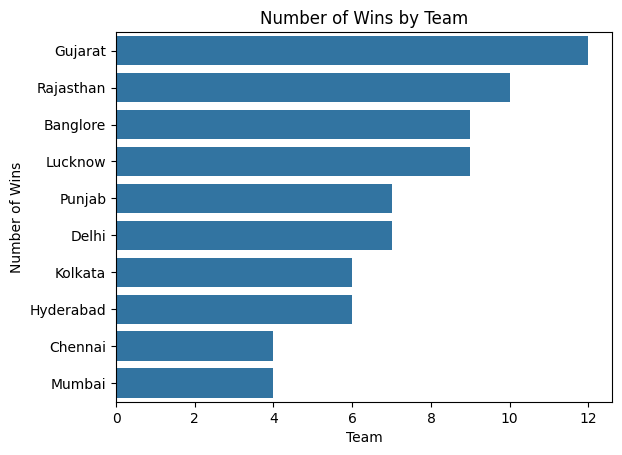

In [10]:
#1.Which team won the most matches?
match_wins = df['match_winner'].value_counts()
sns.barplot(y=match_wins.index,x=match_wins.values)
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.title('Number of Wins by Team')
print(match_wins)

/tmp/ipykernel_11889/1471038132.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=toss_decision_counts.index, y=toss_decision_counts.values,palette='rainbow')


Text(0, 0.5, 'Count')

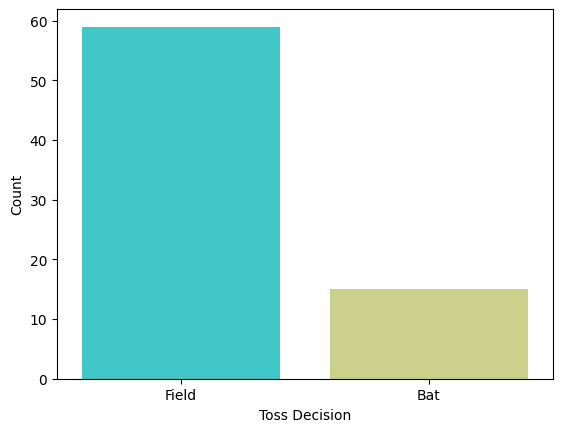

In [12]:
#2.Toss Decision Trends
toss_decision_counts = df['toss_decision'].value_counts()
sns.barplot(x=toss_decision_counts.index, y=toss_decision_counts.values,palette='rainbow')
plt.xlabel('Toss Decision')
plt.ylabel('Count')

In [13]:
#3.Toss Winner vs Match Winner
toss_winner_match_winner = df.groupby(['toss_winner', 'match_winner']).size().reset_index(name='count')
toss_winner_match_winner

,toss_winner,match_winner,count
0,Banglore,Banglore,4
1,Banglore,Chennai,1
2,Banglore,Gujarat,1
3,Banglore,Punjab,1
4,Banglore,Rajasthan,1
5,Chennai,Banglore,1
6,Chennai,Chennai,1
7,Chennai,Gujarat,1
8,Chennai,Punjab,2
9,Chennai,Rajasthan,1


Text(0.5, 1.0, 'Toss Winner vs Match Winner')

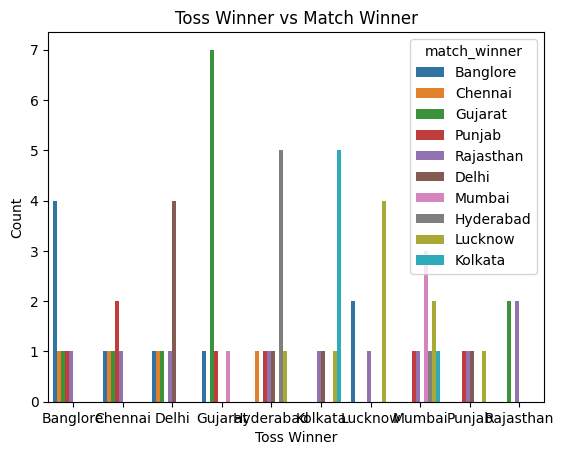

In [14]:
sns.barplot(x='toss_winner', y='count', hue='match_winner', data=toss_winner_match_winner)
plt.xlabel('Toss Winner')
plt.ylabel('Count')
plt.title('Toss Winner vs Match Winner')
#

Text(0.5, 1.0, 'Runs vs Wickets')

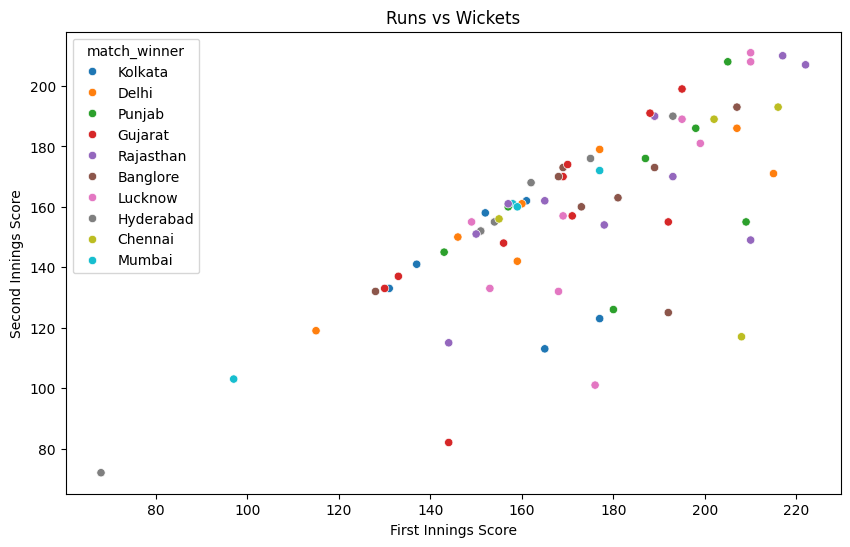

In [15]:
#5.How do teams win? (Runs vs Wickets)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='first_ings_score', y='second_ings_score', hue='match_winner', data=df)
plt.xlabel('First Innings Score')
plt.ylabel('Second Innings Score')
plt.title('Runs vs Wickets')


<Axes: ylabel='player_of_the_match'>

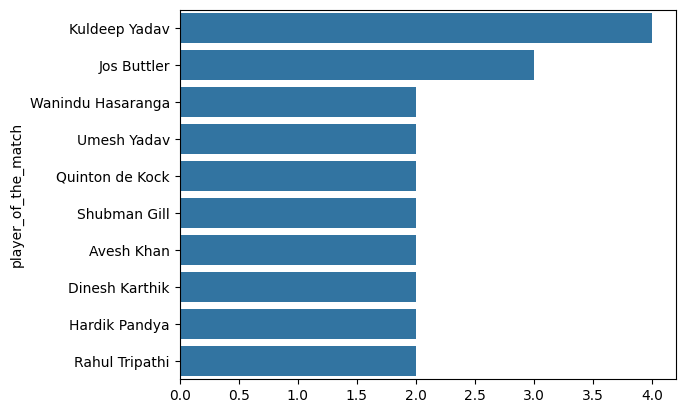

In [18]:
#6.Most "Player of the Match" Awards
player_of_the_match_counts = df['player_of_the_match'].value_counts().head(10)
sns.barplot(x=player_of_the_match_counts.values, y=player_of_the_match_counts.index)

Text(0.5, 1.0, 'Top Scorers')

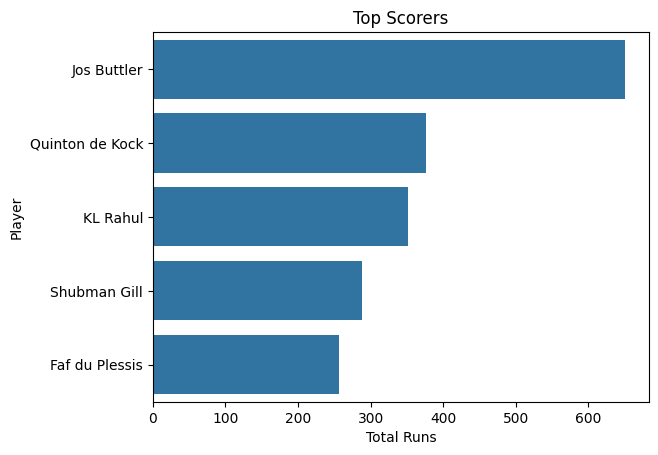

In [21]:
#7. Top Scorers
top_scorers = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_scorers.values, y=top_scorers.index)
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.title('Top Scorers')


<Axes: ylabel='best_bowling'>

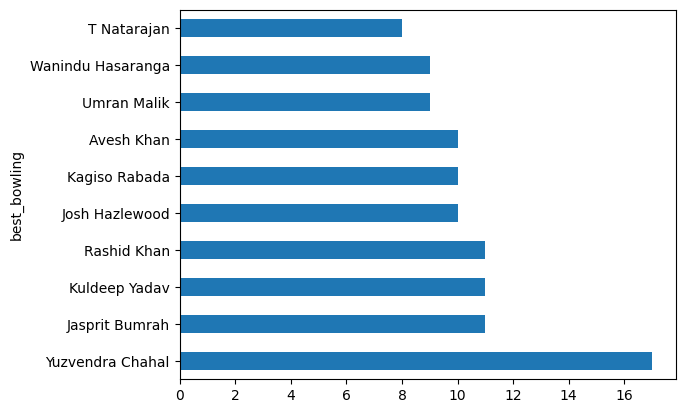

In [24]:
#8.0 Best Bowling Figures
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind = 'barh')

Text(0.5, 1.0, 'Most Matches Played by Venue')

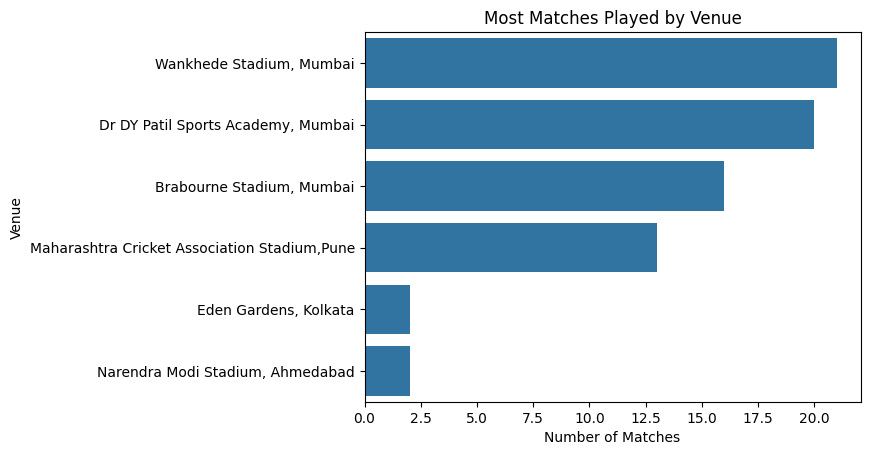

In [25]:
#9Most Matches Played by Venue
venue_counts = df['venue'].value_counts()
sns.barplot(x=venue_counts.values, y=venue_counts.index)
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.title('Most Matches Played by Venue')